# Description
______

This script analyzes HYPE future climate and historical simulations as follows:
- The official Ouranos ESPO-G6-R2 v1.0.0 ensemble which includes 15 models with SSP2-4.5 and SSP3-7.0 for a total of 30 ensemble members is used.
- For each of the 30 members, the mean annual flow volume was calculated (sum of flow for each year then calculate the mean across each year) from 2015 to 2100.
- The models that are closest to the median, 75th percentile and 25th percentile of the mean annual flow volume at SMRIB and MREIB were selected from the 30 members (SSP2-4.5 and SSP3-7.0).
- The average annual hydrographs at both gauges are plotted

### Import Libraries

In [1]:
import xarray as xr
import os
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.parser import ParserError
import cycler
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
import matplotlib.gridspec as gridspec

### Inputs

In [2]:
# Results directory
results_directory = '../../results/v10_1_results/'

# Start and end years for the future climate period
start_year= 2015
end_year= 2100

# Start and end years for historical climate period
hist_start= 1981
hist_end= 2015

# HYPE output variable
variable= 'cout' 

# Path to HYPE output files
# mreib_historical_path= '../../../SMM_Models/hype/model/v10_model/final_model/hds_v3/results/0058308.txt'
# smrib_historical_path= '../../../SMM_Models/hype/model/v10_model/final_model/hds_v3/results/0058208.txt'

mreib_historical_path= '../../../SMM_Models/hype/model/v10_model/final_model/old_hds_v1/results/0058308.txt'
smrib_historical_path= '../../../SMM_Models/hype/model/v10_model/final_model/old_hds_v1/results/0058208.txt'

# Output directory for plots
output_directory= './outputs/'

### Define Functions

In [3]:
def process_average_annual_ensemble(results_directory: str, 
                                     subbasin_id: str, 
                                     scenario: str, 
                                     start_year: int, 
                                     end_year: int, 
                                     variable: str) -> xr.DataArray:
    """
    Processes ensemble data for a specified subbasin, scenario, and variable, 
    filtering by start and end year. Returns a 3D DataArray with dims 
    (member, year, dayofyear) preserving daily variability across years.
    Parameters:
        results_directory (str): Directory containing the ensemble files.
        subbasin_id (str): Subbasin ID to filter the files.
        scenario (str): Scenario identifier to filter the files.
        start_year (int): Start year for filtering data.
        end_year (int): End year for filtering data.
        variable (str): Variable name to select from the dataset.
    Returns:
        xr.DataArray: Processed data with dims (member, year, dayofyear), 
                      shifted to start on October 1st.
    """
    exclude_members = [
        "CanESM5", "CNRM-CM6-1", "EC-Earth3", "IPSL-CM6A-LR", "UKESM1-0-LL",
        "NorESM2-MM", "EC-Earth3-CC", "NESM3", "EC-Earth3-Veg", "INM-CM4-8", "TaiESM1"
    ]

    file_list = [os.path.join(results_directory, filename) 
                 for filename in os.listdir(results_directory) 
                 if (subbasin_id in filename) and (scenario in filename)]

    data_arrays: List[xr.DataArray] = []
    for file_path in file_list:
        if any(member in file_path for member in exclude_members):
            continue
        df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False)
        df = df.iloc[1:]
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'), 
                                  coords={'DATE': df.index, 'variable': df.columns})
        data_arrays.append(data_array)

    ds = xr.concat(data_arrays, dim='member')
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')
    ds = ds.astype(float)

    # Select variable, sort, and filter by year
    var_data = ds.sel(variable=variable)
    var_data = var_data.sortby('DATE')
    var_data = var_data.sel(DATE=(var_data['DATE'].dt.year >= start_year) & 
                                  (var_data['DATE'].dt.year <= end_year))

    # Drop leap days
    var_data = var_data.sel(DATE=~(var_data['DATE'].dt.dayofyear == 366))

    # Assign year and dayofyear as coordinates for unstacking
    var_data = var_data.assign_coords(
        year=('DATE', var_data['DATE'].dt.year.values),
        doy=('DATE', var_data['DATE'].dt.dayofyear.values)
    )

    # Reshape from (member, DATE) → (member, year, dayofyear)
    var_data_3d = var_data.set_index(DATE=['year', 'doy']).unstack('DATE')
    var_data_3d = var_data_3d.rename({'doy': 'dayofyear'})

    # Shift dayofyear to start on October 1st
    shifted_doy = ((var_data_3d['dayofyear'] - 274) % 365) + 1
    var_data_3d = var_data_3d.assign_coords(dayofyear=shifted_doy)
    var_data_3d = var_data_3d.sortby('dayofyear')

    return var_data_3d  # dims: (member, year, dayofyear)

In [4]:
def process_historical(filepath: str, variable: str, start_date: str = '1981-01-01', end_date: str = '2015-12-31') -> pd.Series:
    """
    Processes historical data from HYPE output files into an average annual timeseries

    Parameters:
        filepath (str): Path to the HYPE output file.
        variable (str): The variable name in the file to process.
        start_date (str): The start date for the data filter (default is '1981-01-01').
        end_date (str): The end date for the data filter (default is '2015-12-31').

    Returns:
        pd.Series: A pandas Series with the historical average annual timeseries
    """
    
    # Read the tab-separated text file into a DataFrame
    sim: pd.DataFrame = pd.read_csv(filepath, delimiter='\t', index_col=0, low_memory=False)
    
    # Drop the first row
    sim = sim.iloc[1:]
    
    # Drop all columns except for 'variable'
    sim = sim[[variable]]
    
    # Convert index to datetime
    sim.index = pd.to_datetime(sim.index)
    
    # Trim the DataFrame between dates
    sim = sim.loc[start_date:end_date]
    
    # Get the length of the DataFrame before dropping NaN values
    original_length: int = len(sim)
    
    # Convert the 'variable' column to numeric
    sim[variable] = pd.to_numeric(sim[variable], errors='coerce')

    # Replace -9999 values with NaN
    sim[variable] = sim[variable].replace(-9999, pd.NA)
    
    # Drop NaN values if any
   # sim = sim.dropna()
    
    # Get the length of the DataFrame after dropping NaN values
    new_length: int = len(sim)
    
    # Check if any NaN values were replaced
    if new_length < original_length:
        print("NaN values were replaced during conversion.")

    # Resample the data to calculate the mean for each day of the year across all years default is .mean()
    sim_resampled: pd.Series = sim.groupby(sim.index.dayofyear)[variable].median()

    # Drop leap day (dayofyear = 366) if it exists to be consistent with future climate members
    sim_resampled = sim_resampled[sim_resampled.index != 366]

    # Shift dayofyear to start on October 1st and wrap around
    dayofyear_shifted = ((sim_resampled.index - 274) % 365) + 1

    # Update the index of the Series with the shifted dayofyear values
    sim_resampled.index = dayofyear_shifted

    # Sort the Series by index to ensure the correct order
    sim_shifted = sim_resampled.sort_index()
    
    return sim_shifted

In [5]:
def process_historical_with_percentiles(
    filepath: str, variable: str,
    start_date: str = '1981-01-01', end_date: str = '2015-12-31'
) -> tuple[pd.Series, pd.Series]:
    """
    Same pipeline as process_historical but returns (q25, q75) across years
    for each day of year, useful for shading interannual spread.
    """
    sim = pd.read_csv(filepath, delimiter='\t', index_col=0, low_memory=False)
    sim = sim.iloc[1:]
    sim = sim[[variable]]
    sim.index = pd.to_datetime(sim.index)
    sim = sim.loc[start_date:end_date]
    sim[variable] = pd.to_numeric(sim[variable], errors='coerce')
    # Replace -9999 values with NaN
    sim[variable] = sim[variable].replace(-9999, np.nan)  # np.nan instead of pd.NA

    grouped = sim.groupby(sim.index.dayofyear)[variable]
    q25 = grouped.quantile(0.25)
    q75 = grouped.quantile(0.75)

    for s in (q25, q75):
        s.drop(index=366, errors='ignore', inplace=True)

    def shift_index(s):
        shifted_idx = ((s.index - 274) % 365) + 1
        s.index = shifted_idx
        return s.sort_index()

    return shift_index(q25), shift_index(q75)

### Prepare data

In [6]:

# Create average annual pseudo historical for MREIB ssp245
mreib_hist_ssp245= process_average_annual_ensemble(results_directory, '58308', 'ssp245', hist_start, hist_end, variable)

In [7]:

# Create average annual pseudo historical for MREIB ssp370
mreib_hist_ssp370 = process_average_annual_ensemble(results_directory, '58308', 'ssp370', hist_start, hist_end,  variable)

In [8]:

# Create average annual pseudo historical for SMRIB ssp245
smrib_hist_ssp245 = process_average_annual_ensemble(results_directory, '58208', 'ssp245', hist_start, hist_end, variable)

In [9]:

# Create average annual pseudo historical for SMRIB ssp370
smrib_hist_ssp370 = process_average_annual_ensemble(results_directory, '58208', 'ssp370', hist_start, hist_end, variable)

In [10]:
# Extract historical data for SMRIB and MREIB
mreib_historical= process_historical(mreib_historical_path, variable, start_date="1981-01-01", end_date="2015-12-31")
smrib_historical= process_historical(smrib_historical_path, variable, start_date="1981-01-01", end_date="2015-12-31")

# Extract observed data for SMRIB and MREIB
mreib_obs_historical= process_historical(mreib_historical_path, 'rout', start_date="1981-01-01", end_date="2015-12-31")
smrib_obs_historical= process_historical(smrib_historical_path, 'rout', start_date="1981-01-01", end_date="2015-12-31")

/work/comphyd_lab/local/modules/spack/2024v5/core/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder/linux-rocky8-x86_64/gcc-14.2.0/py-numpy-1.26.4-4gvcfkg7xzi7ktldzplfxodbfcjqoyf3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/work/comphyd_lab/local/modules/spack/2024v5/core/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder/linux-rocky8-x86_64/gcc-14.2.0/py-numpy-1.26.4-4gvcfkg7xzi7ktldzplfxodbfcjqoyf3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/work/comphyd_lab/local/modules/spack/2024v5/core/__spack_path_placeholder__/__spack_path_placeholder__/__spack_path_placeholder/linux-rocky8-x86_64/gcc-14.2.0/py-numpy-1.26.4-4gvcfkg7xzi7ktldzplfxodbfcjqoyf3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: Runt

In [11]:
# SMRIB percentile bounds
smrib_hist_q25, smrib_hist_q75 = process_historical_with_percentiles(
    smrib_historical_path, variable
)
if variable == 'cout':
    smrib_obs_q25, smrib_obs_q75 = process_historical_with_percentiles(
        smrib_historical_path, 'rout'
    )

# MREIB percentile bounds
mreib_hist_q25, mreib_hist_q75 = process_historical_with_percentiles(
    mreib_historical_path, variable
)
if variable == 'cout':
    mreib_obs_q25, mreib_obs_q75 = process_historical_with_percentiles(
        mreib_historical_path, 'rout'
    )

In [12]:
# Create a dictionary to map variables to corresponding names and units
variable_dict = {
    'cout': {'name': 'Streamflow', 'unit': 'cms'},
    'upsnow': {'name': 'Mean Upstream SWE', 'unit': 'mm'},
    'upsoim': {'name': 'Mean Upstream Soil Moisture', 'unit': 'mm'},
    'upcprc': {'name': 'Mean Upstream Precipitation', 'unit': 'mm/day'},
    'upctmp': {'name': 'Mean Upstream Temperature', 'unit': 'C'}
}

# Assuming `variable` is one of the keys in the dictionary
variable_name = variable_dict[variable]['name']
variable_unit = variable_dict[variable]['unit']

### Updated Plots : Fig 1

In [13]:
def plot_historical_only(
    historical: pd.Series,
    hist_q25: pd.Series,
    hist_q75: pd.Series,
    variable_name: str,
    variable_unit: str,
    variable: str,
    output_directory: str,
    basin_name: str,
    obs_historical: pd.Series = None,
    obs_q25: pd.Series = None,
    obs_q75: pd.Series = None,
):
    """
    Plots RDRSv2.1 historical median + IQR, and optionally naturalized 
    observed historical median + IQR when variable == 'cout'.
    Parameters:
        historical:       Median annual cycle from process_historical (pd.Series)
        hist_q25:         Q25 from process_historical_with_percentiles (pd.Series)
        hist_q75:         Q75 from process_historical_with_percentiles (pd.Series)
        variable_name:    Human-readable variable name for axis label
        variable_unit:    Unit string for axis label
        variable:         Variable code for filename
        output_directory: Output path for saved figure
        basin_name:       Basin identifier for title and filename
        obs_historical:   Naturalized observed median annual cycle (optional)
        obs_q25:          Naturalized observed Q25 (optional)
        obs_q75:          Naturalized observed Q75 (optional)
    """
    historical_forcing_color = '#e74c3c'   # vivid red    — RDRSv2.1
    historical_obs_color     = '#2c3e50'   # dark slate   — naturalized observed

    plt.figure(figsize=(16, 8))

    # --- RDRSv2.1 historical median + IQR ---
    historical.plot(color=historical_forcing_color,
                    label='RDRSv2.1 Historical Median (1981–2015)')
    plt.fill_between(
        hist_q25.index,
        hist_q25,
        hist_q75,
        color=historical_forcing_color,
        alpha=0.2
    )

    # --- Naturalized observed median + IQR (cout only) ---
    if variable == 'cout' and obs_historical is not None:
        obs_historical.plot(color=historical_obs_color, alpha=0.8,
                            label='Naturalized Historical Median (1981–2015)')
        plt.fill_between(
            obs_q25.index,
            obs_q25,
            obs_q75,
            color=historical_obs_color,
            alpha=0.15
        )

    # --- Legend ---
    legend_handles = [
        Line2D([0], [0], color=historical_forcing_color, lw=2,
               label='RDRSv2.1 Historical Median (1981–2015)'),
        Patch(facecolor=historical_forcing_color, alpha=0.2,
              label='RDRSv2.1 Historical IQR (25th–75th Percentile)'),
    ]
    if variable == 'cout' and obs_historical is not None:
        legend_handles += [
            Line2D([0], [0], color=historical_obs_color, lw=2, alpha=0.8,
                   label='Naturalized Historical Median (1981–2015)'),
            Patch(facecolor=historical_obs_color, alpha=0.15,
                  label='Naturalized Historical IQR (25th–75th Percentile)'),
        ]
    plt.legend(handles=legend_handles, fontsize=9)

    plt.xlabel('Day of Year (Starting Oct 1st)')
    plt.ylabel(f'Average Daily {variable_name} ({variable_unit})')
    plt.title(f'{basin_name} Average Daily {variable_name} — '
              f'Naturalized Historical vs. RDRSv2.1 Historical Median (1981–2015)')

    file_path = os.path.join(output_directory,
                             f'{basin_name}_historical_only_{variable}.png')
    plt.savefig(file_path, bbox_inches='tight')
    plt.show()

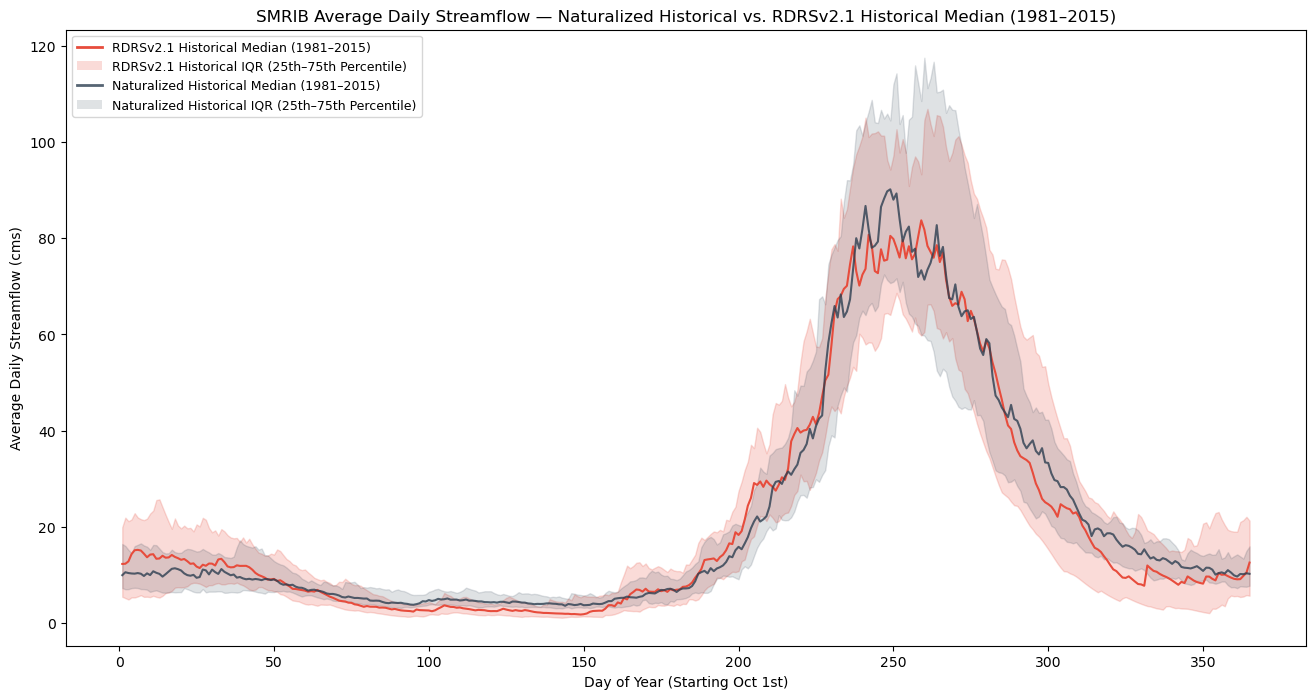

In [14]:
# SMRIB
plot_historical_only(
    historical=smrib_historical,
    hist_q25=smrib_hist_q25,
    hist_q75=smrib_hist_q75,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='SMRIB',
    obs_historical=smrib_obs_historical,
    obs_q25=smrib_obs_q25,
    obs_q75=smrib_obs_q75
)

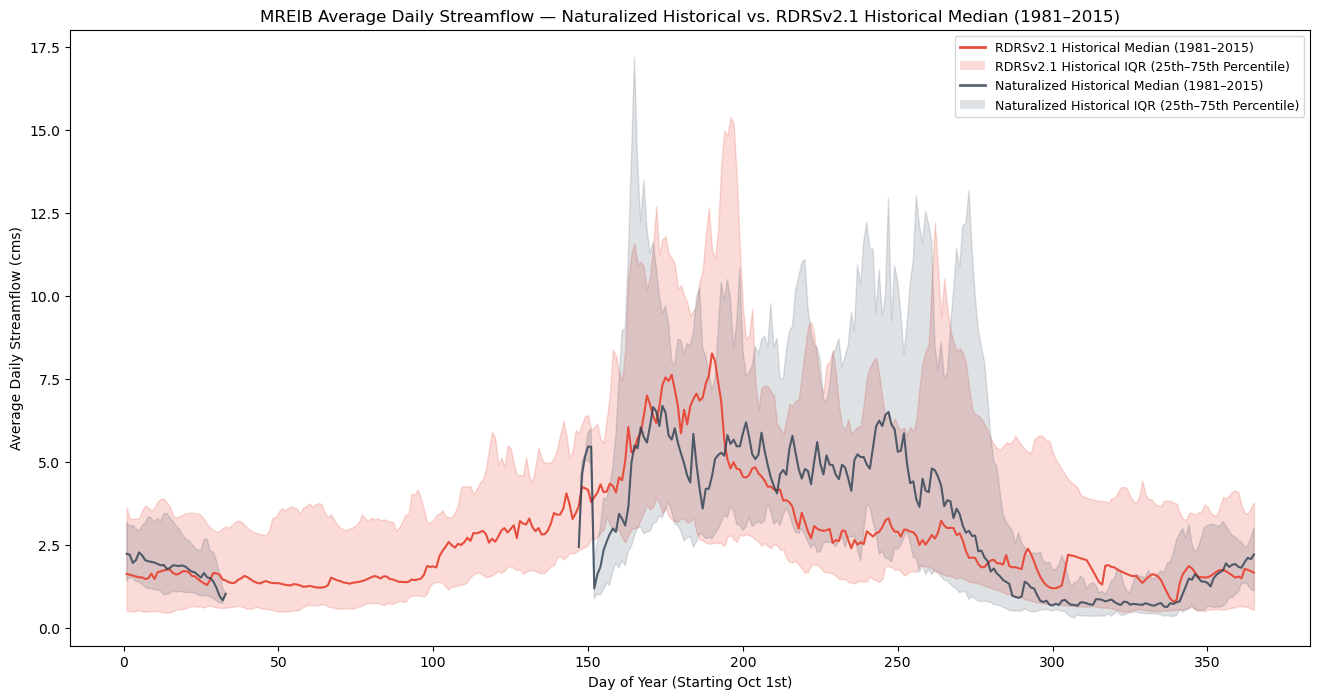

In [15]:
# MREIB
plot_historical_only(
    historical=mreib_historical,
    hist_q25=mreib_hist_q25,
    hist_q75=mreib_hist_q75,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='MREIB',
    obs_historical=mreib_obs_historical,
    obs_q25=mreib_obs_q25,
    obs_q75=mreib_obs_q75
)

### Updated Plots : Fig 2

In [16]:
def plot_historical_vs_pseudohistorical(
    historical: pd.Series,
    hist_q25: pd.Series,
    hist_q75: pd.Series,
    hist_ssp245: xr.DataArray,
    hist_ssp370: xr.DataArray,
    variable_name: str,
    variable_unit: str,
    variable: str,
    output_directory: str,
    basin_name: str
):
    historical_forcing_color  = '#e74c3c'   # vivid red     — RDRSv2.1.
    historical_ensemble_color = '#2c7bb6'   # strong blue   — pseudo-historical ensemble

    plt.figure(figsize=(16, 8))

    # --- RDRSv2.1 historical mean + IQR ---
    historical.plot(color=historical_forcing_color,
                    label='RDRSv2.1. Historical Median (1981-2015)')
    plt.fill_between(
        hist_q25.index,
        hist_q25,
        hist_q75,
        color=historical_forcing_color,
        alpha=0.2
    )

    # --- Combined pseudo-historical ensemble (SSP2-4.5 + SSP3-7.0) ---
    # Concatenate along member dimension to pool all 30 members x 35 years = 1050 samples
    combined = xr.concat([hist_ssp245, hist_ssp370], dim='member')
    stacked = combined.stack(sample=('member', 'year'))

    median = stacked.median(dim='sample')
    q25 = stacked.quantile(0.25, dim='sample')
    q75 = stacked.quantile(0.75, dim='sample')

    median.plot(color=historical_ensemble_color, linestyle='-')
    plt.fill_between(
        combined['dayofyear'].values,
        q25,
        q75,
        color=historical_ensemble_color,
        alpha=0.2
    )

    # --- Legend ---
    legend_handles = [
        Line2D([0], [0], color=historical_forcing_color, lw=2,
               label='RDRSv2.1. Historical (1981-2015)'),
        Patch(facecolor=historical_forcing_color, alpha=0.2,
              label='RDRSv2.1. Historical IQR (25th–75th Percentile)'),
        Line2D([0], [0], color=historical_ensemble_color, lw=2,
               label='Historical Climate Ensemble Median (1981-2015)'),
        Patch(facecolor=historical_ensemble_color, alpha=0.2,
              label='Historical Climate Ensemble IQR (25th–75th Percentile)'),
    ]
    plt.legend(handles=legend_handles, fontsize=9)

    plt.xlabel('Day of Year (Starting Oct 1st)')
    plt.ylabel(f'Average Daily {variable_name} ({variable_unit})')
    plt.title(f'{basin_name} Average Daily {variable_name} — '
              f'RDRSv2.1. vs Historical Climate Ensembles (1981-2015)')

    file_path = os.path.join(output_directory,
                             f'{basin_name}_historical_vs_historical_climate_{variable}.png')
    plt.savefig(file_path, bbox_inches='tight')
    plt.show()

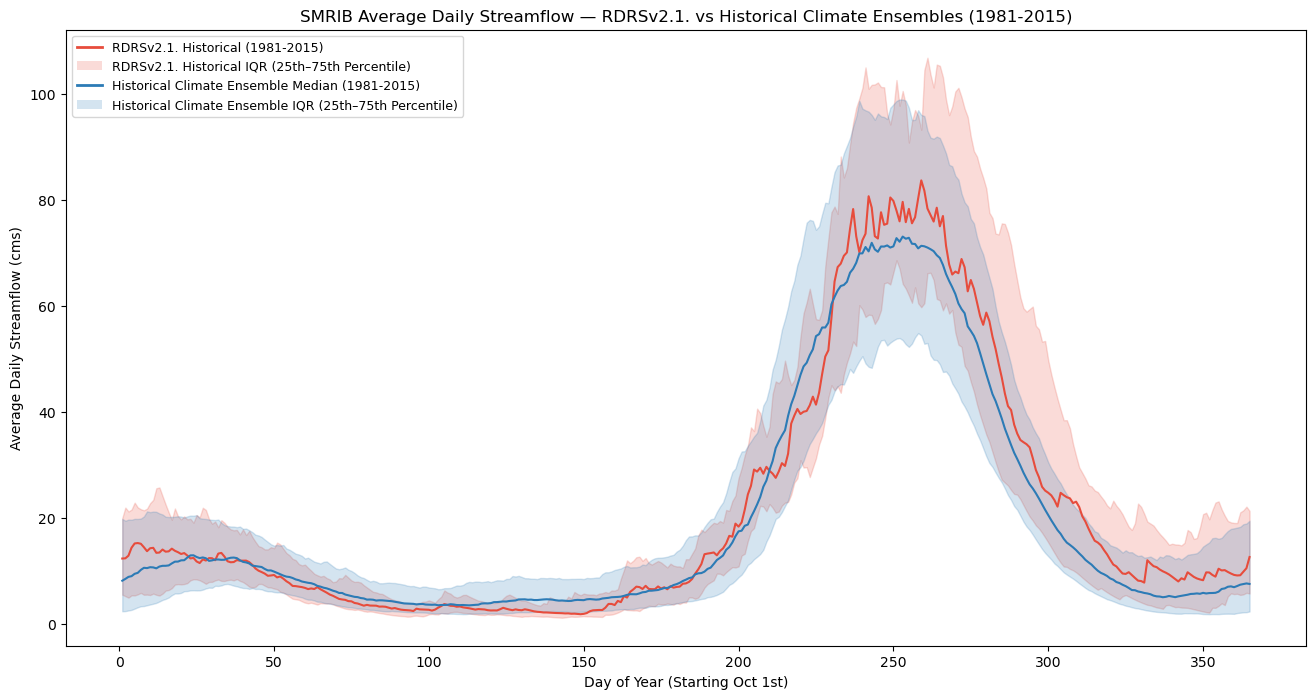

In [17]:
plot_historical_vs_pseudohistorical(
    historical=smrib_historical,
    hist_q25=smrib_hist_q25,
    hist_q75=smrib_hist_q75,
    hist_ssp245=smrib_hist_ssp245,
    hist_ssp370=smrib_hist_ssp370,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='SMRIB'
)

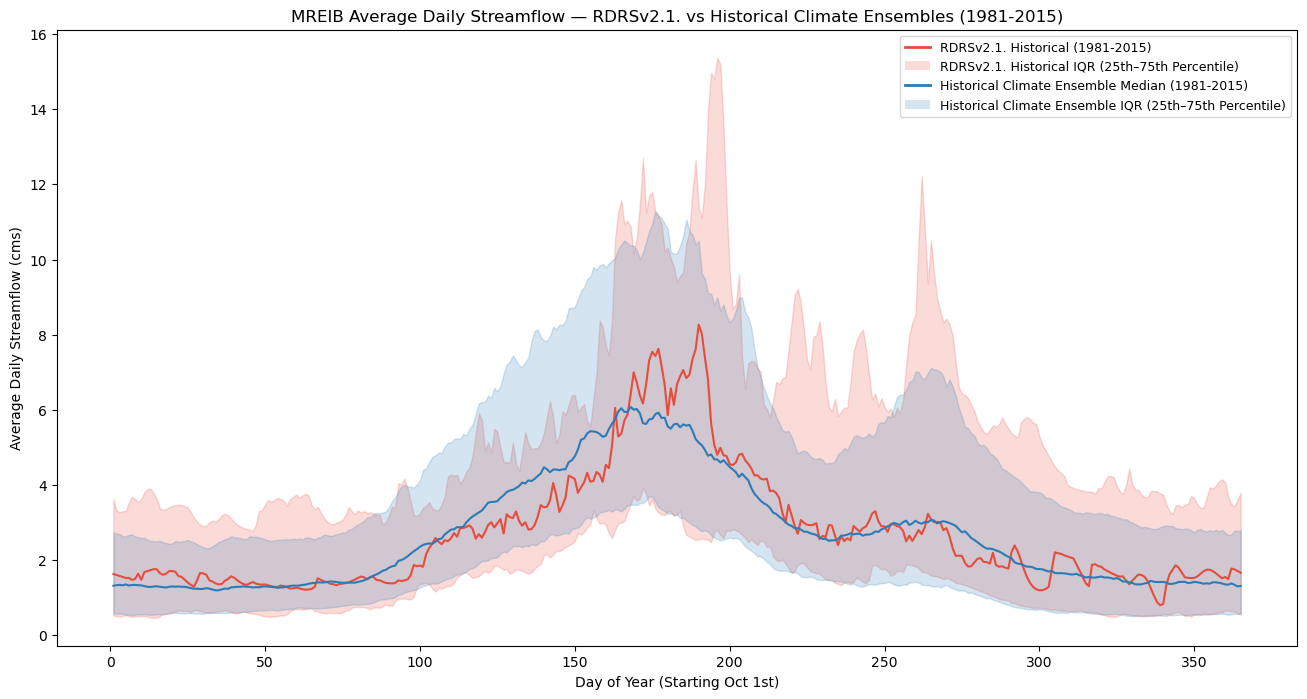

In [18]:
plot_historical_vs_pseudohistorical(
    historical=mreib_historical,
    hist_q25=mreib_hist_q25,
    hist_q75=mreib_hist_q75,
    hist_ssp245=mreib_hist_ssp245,
    hist_ssp370=mreib_hist_ssp370,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='MREIB'
)

### Updated Plots : Fig 3

In [19]:
# Near future (2021-2055)
smrib_ssp245_near = process_average_annual_ensemble(results_directory, '58208', 'ssp245', 2021, 2055, variable)
smrib_ssp370_near = process_average_annual_ensemble(results_directory, '58208', 'ssp370', 2021, 2055, variable)

# Far future (2076-2100)
smrib_ssp245_far = process_average_annual_ensemble(results_directory, '58208', 'ssp245', 2076, 2100, variable)
smrib_ssp370_far = process_average_annual_ensemble(results_directory, '58208', 'ssp370', 2076, 2100, variable)

In [20]:
# Near future (2021-2055)
mreib_ssp245_near = process_average_annual_ensemble(results_directory, '58308', 'ssp245', 2021, 2055, variable)
mreib_ssp370_near = process_average_annual_ensemble(results_directory, '58308', 'ssp370', 2021, 2055, variable)

# Far future (2076-2100)
mreib_ssp245_far = process_average_annual_ensemble(results_directory, '58308', 'ssp245', 2076, 2100, variable)
mreib_ssp370_far = process_average_annual_ensemble(results_directory, '58308', 'ssp370', 2076, 2100, variable)


In [21]:
def plot_pseudohistorical_vs_future(
    hist_ssp245: xr.DataArray,
    hist_ssp370: xr.DataArray,
    ssp245_near: xr.DataArray,
    ssp370_near: xr.DataArray,
    ssp245_far: xr.DataArray,
    ssp370_far: xr.DataArray,
    variable_name: str,
    variable_unit: str,
    variable: str,
    output_directory: str,
    basin_name: str
):
    # Colors — hue = scenario, lightness = time period
    historical_color = '#2ca02c'    # strong green — stands apart from both scenario families
    near_color1      = '#74b9ff'    # light blue   — SSP2-4.5 near
    far_color1       = '#0047AB'    # cobalt blue  — SSP2-4.5 far
    near_color2      = '#fab1a0'    # light salmon — SSP3-7.0 near
    far_color2       = '#c0392b'    # strong red   — SSP3-7.0 far

    plt.figure(figsize=(16, 8))

    # Helper to compute median + IQR from 3D DataArray
    def get_stats(data):
        stacked = data.stack(sample=('member', 'year'))
        return (
            stacked.median(dim='sample'),
            stacked.quantile(0.25, dim='sample'),
            stacked.quantile(0.75, dim='sample')
        )

    # Combined pseudo-historical
    hist_combined = xr.concat([hist_ssp245, hist_ssp370], dim='member')
    hist_median, hist_q25, hist_q75 = get_stats(hist_combined)

    # All five traces
    traces = [
        (hist_combined,  historical_color, 'Historical Climate Combined Median (1981–2015)'),
        (ssp245_near,    near_color1,      'SSP2-4.5 Near-Future Median (2021–2055)'),
        (ssp370_near,    near_color2,      'SSP3-7.0 Near-Future Median (2021–2055)'),
        (ssp245_far,     far_color1,       'SSP2-4.5 Far-Future Median (2076–2100)'),
        (ssp370_far,     far_color2,       'SSP3-7.0 Far-Future Median (2076–2100)'),
    ]

    legend_handles = []
    for data, color, label in traces:
        median, q25, q75 = get_stats(data)
        median.plot(color=color, linestyle='-')
        plt.fill_between(
            data['dayofyear'].values,
            q25,
            q75,
            color=color,
            alpha=0.2
        )
        legend_handles += [
            Line2D([0], [0], color=color, lw=2, label=label),
            Patch(facecolor=color, alpha=0.2,
                  label=label.replace('Median', 'IQR (25th–75th Percentile)')),
        ]

    plt.legend(handles=legend_handles,  fontsize=9)
    plt.xlabel('Day of Year (Starting Oct 1st)')
    plt.ylabel(f'Average Daily {variable_name} ({variable_unit})')
    plt.title(f'{basin_name} Average Daily {variable_name} — '
              f'Historical Climate vs Near and Far Future')

    file_path = os.path.join(output_directory,
                             f'{basin_name}_historical_climate_vs_future_{variable}.png')
    plt.savefig(file_path, bbox_inches='tight')
    plt.show()

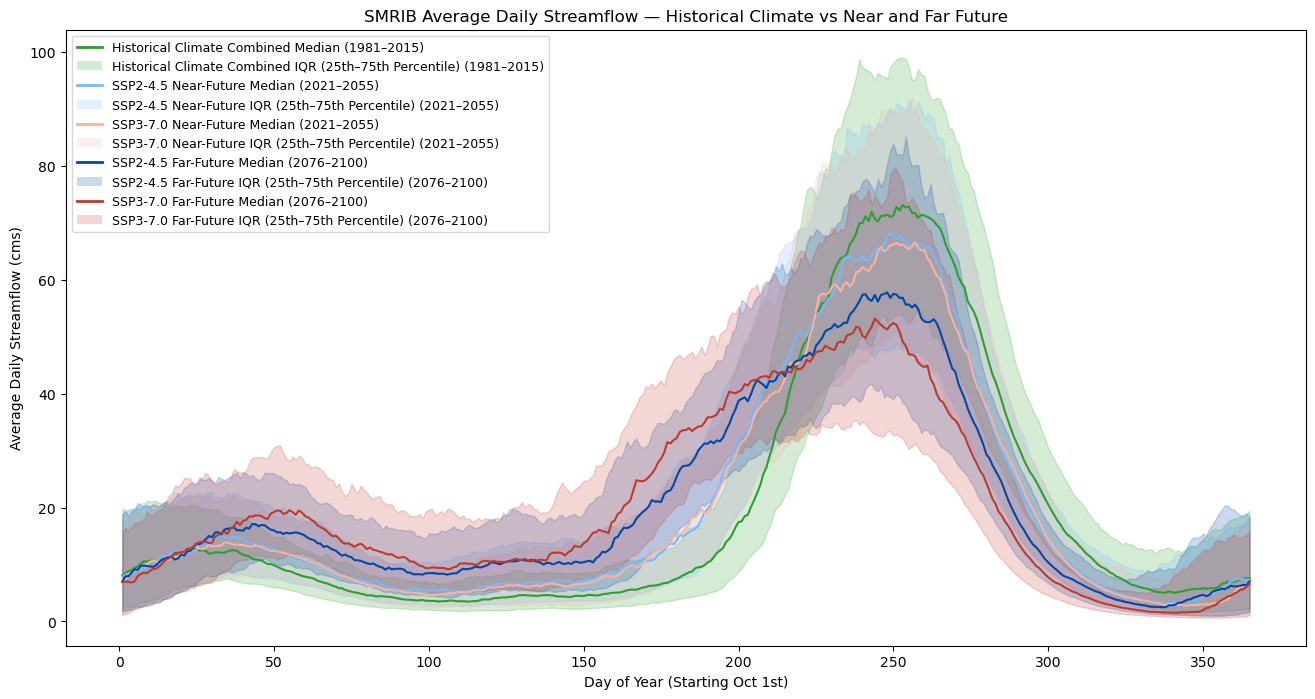

In [22]:
plot_pseudohistorical_vs_future(
    hist_ssp245=smrib_hist_ssp245,
    hist_ssp370=smrib_hist_ssp370,
    ssp245_near=smrib_ssp245_near,
    ssp370_near=smrib_ssp370_near,
    ssp245_far=smrib_ssp245_far,
    ssp370_far=smrib_ssp370_far,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='SMRIB'
)

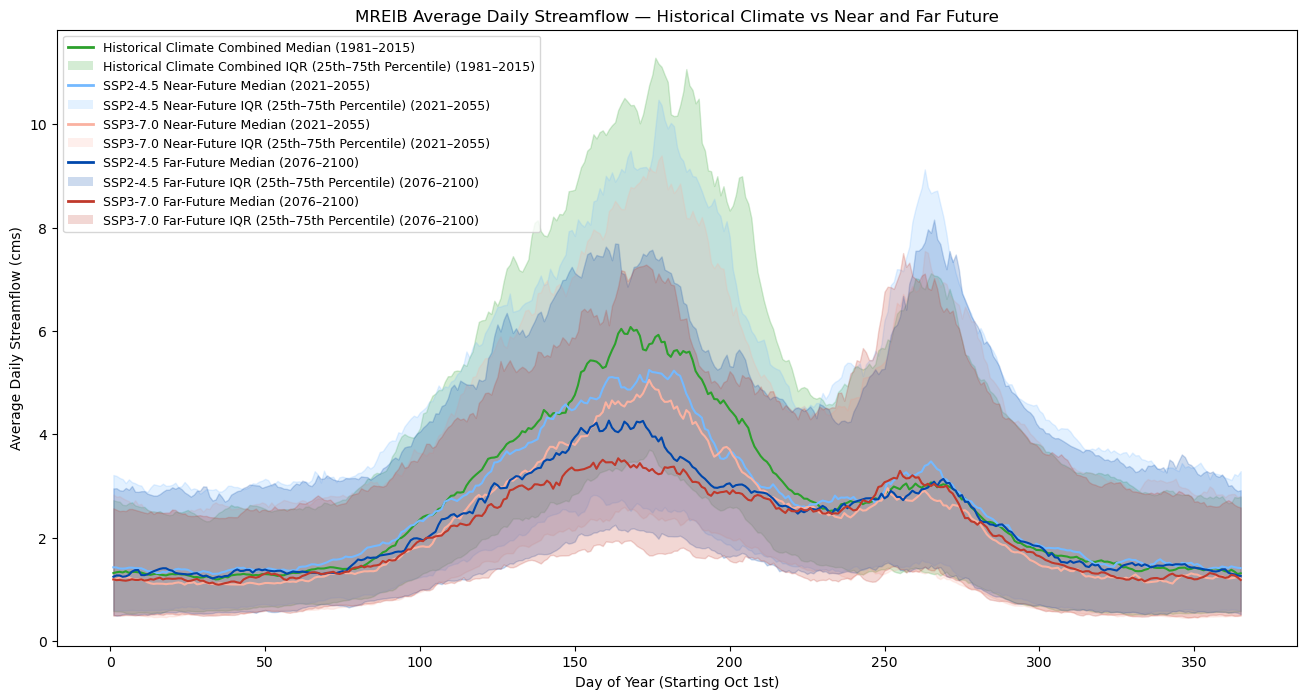

In [23]:
plot_pseudohistorical_vs_future(
    hist_ssp245=mreib_hist_ssp245,
    hist_ssp370=mreib_hist_ssp370,
    ssp245_near=mreib_ssp245_near,
    ssp370_near=mreib_ssp370_near,
    ssp245_far=mreib_ssp245_far,
    ssp370_far=mreib_ssp370_far,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='MREIB'
)

### Alternate 3rd Plots

In [33]:
def plot_pseudohistorical_vs_future_splitssp(
    hist_ssp245: xr.DataArray,
    hist_ssp370: xr.DataArray,
    ssp245_near: xr.DataArray,
    ssp370_near: xr.DataArray,
    ssp245_far: xr.DataArray,
    ssp370_far: xr.DataArray,
    variable_name: str,
    variable_unit: str,
    variable: str,
    output_directory: str,
    basin_name: str
):
    historical_color = '#2ca02c'
    near_color1      = '#74b9ff'
    far_color1       = '#0047AB'
    near_color2      = '#fab1a0'
    far_color2       = '#c0392b'

    def get_stats(data):
        stacked = data.stack(sample=('member', 'year'))
        return (
            stacked.median(dim='sample'),
            stacked.quantile(0.25, dim='sample'),
            stacked.quantile(0.75, dim='sample'),
        )

    hist_combined = xr.concat([hist_ssp245, hist_ssp370], dim='member')
    hist_median, hist_q25, hist_q75 = get_stats(hist_combined)
    doy = hist_combined['dayofyear'].values

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    panel_configs = [
        {
            'ax':     axes[0],
            'title':  'SSP2-4.5',
            'traces': [
                (hist_combined, historical_color, 'Historical Climate Combined (1981–2015)'),
                (ssp245_near,   near_color1,      'SSP2-4.5 Near-Future (2021–2055)'),
                (ssp245_far,    far_color1,        'SSP2-4.5 Far-Future (2076–2100)'),
            ],
        },
        {
            'ax':     axes[1],
            'title':  'SSP3-7.0',
            'traces': [
                (hist_combined, historical_color, 'Historical Climate Combined (1981–2015)'),
                (ssp370_near,   near_color2,      'SSP3-7.0 Near-Future (2021–2055)'),
                (ssp370_far,    far_color2,        'SSP3-7.0 Far-Future (2076–2100)'),
            ],
        },
    ]

    for cfg in panel_configs:
        ax = cfg['ax']
        legend_handles = []

        for data, color, label in cfg['traces']:
            median, q25, q75 = get_stats(data)
            ax.plot(doy, median, color=color, linestyle='-', lw=1.8)
            ax.fill_between(doy, q25, q75, color=color, alpha=0.2)
            legend_handles += [
                Line2D([0], [0], color=color, lw=2, label=label),
                Patch(facecolor=color, alpha=0.2,
                      label=label.replace('(', 'IQR (')),
            ]

        ax.set_title(f'{basin_name} — {cfg["title"]}\n'
                     f'Historical vs Near & Far Future {variable_name}',
                     fontsize=11)
        ax.set_xlabel('Day of Year (Starting Oct 1st)')
        ax.legend(handles=legend_handles, fontsize=8.5, loc='best')

    axes[0].set_ylabel(f'Average Daily {variable_name} ({variable_unit})')
    axes[1].set_ylabel('')  # shared axis — suppress duplicate label

    fig.suptitle(
        f'{basin_name} — Average Daily {variable_name}: Historical vs Future Climate',
        fontsize=13, fontweight='bold', y=1.01
    )

    plt.tight_layout()
    file_path = os.path.join(
        output_directory,
        f'{basin_name}_historical_climate_vs_future_{variable}_split_ssp.png'
    )
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()

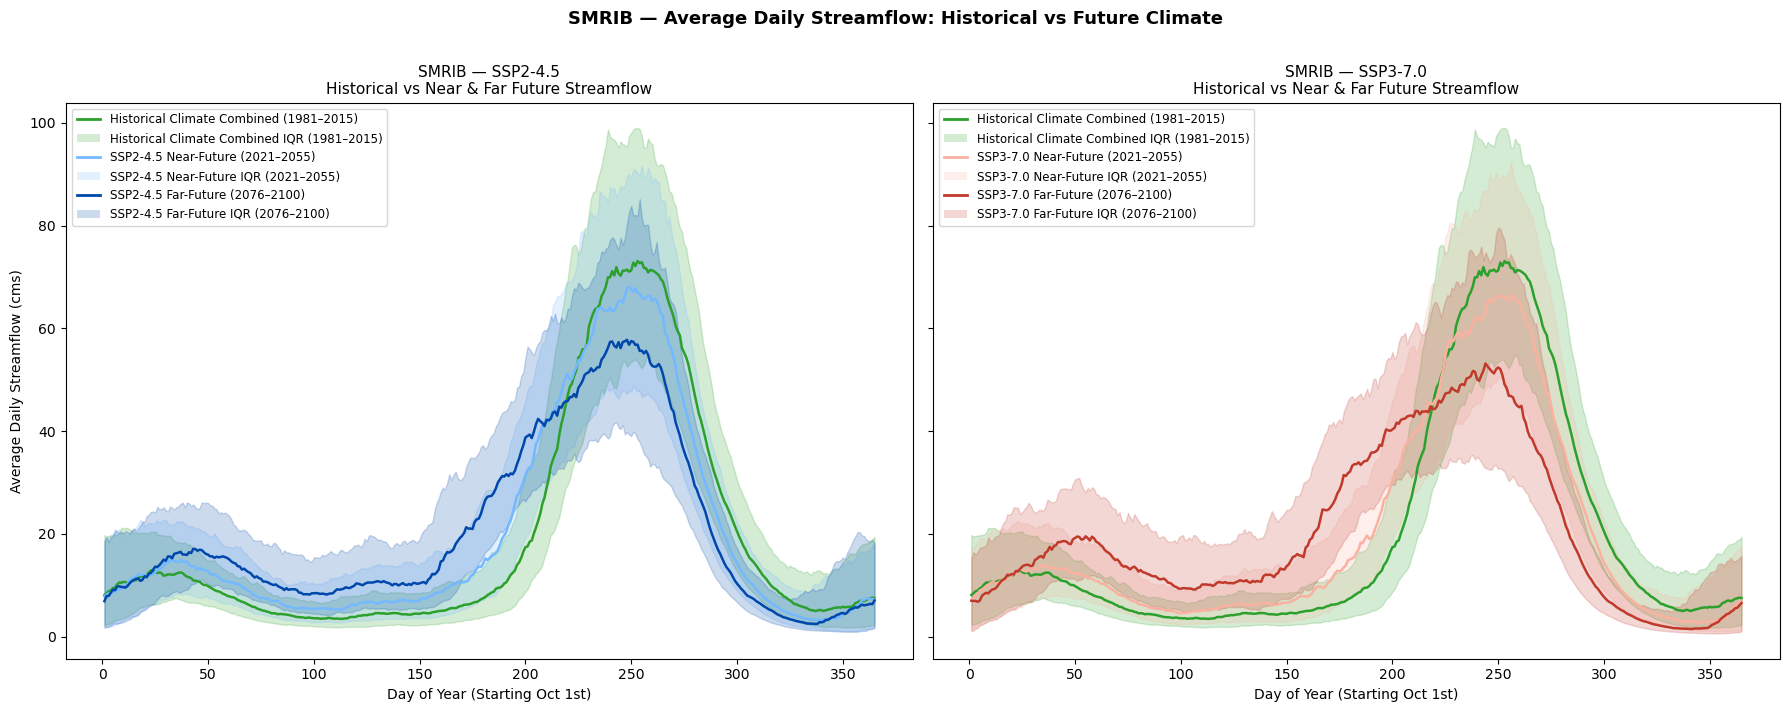

In [34]:
plot_pseudohistorical_vs_future_splitssp(
    hist_ssp245=smrib_hist_ssp245,
    hist_ssp370=smrib_hist_ssp370,
    ssp245_near=smrib_ssp245_near,
    ssp370_near=smrib_ssp370_near,
    ssp245_far=smrib_ssp245_far,
    ssp370_far=smrib_ssp370_far,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='SMRIB'
)

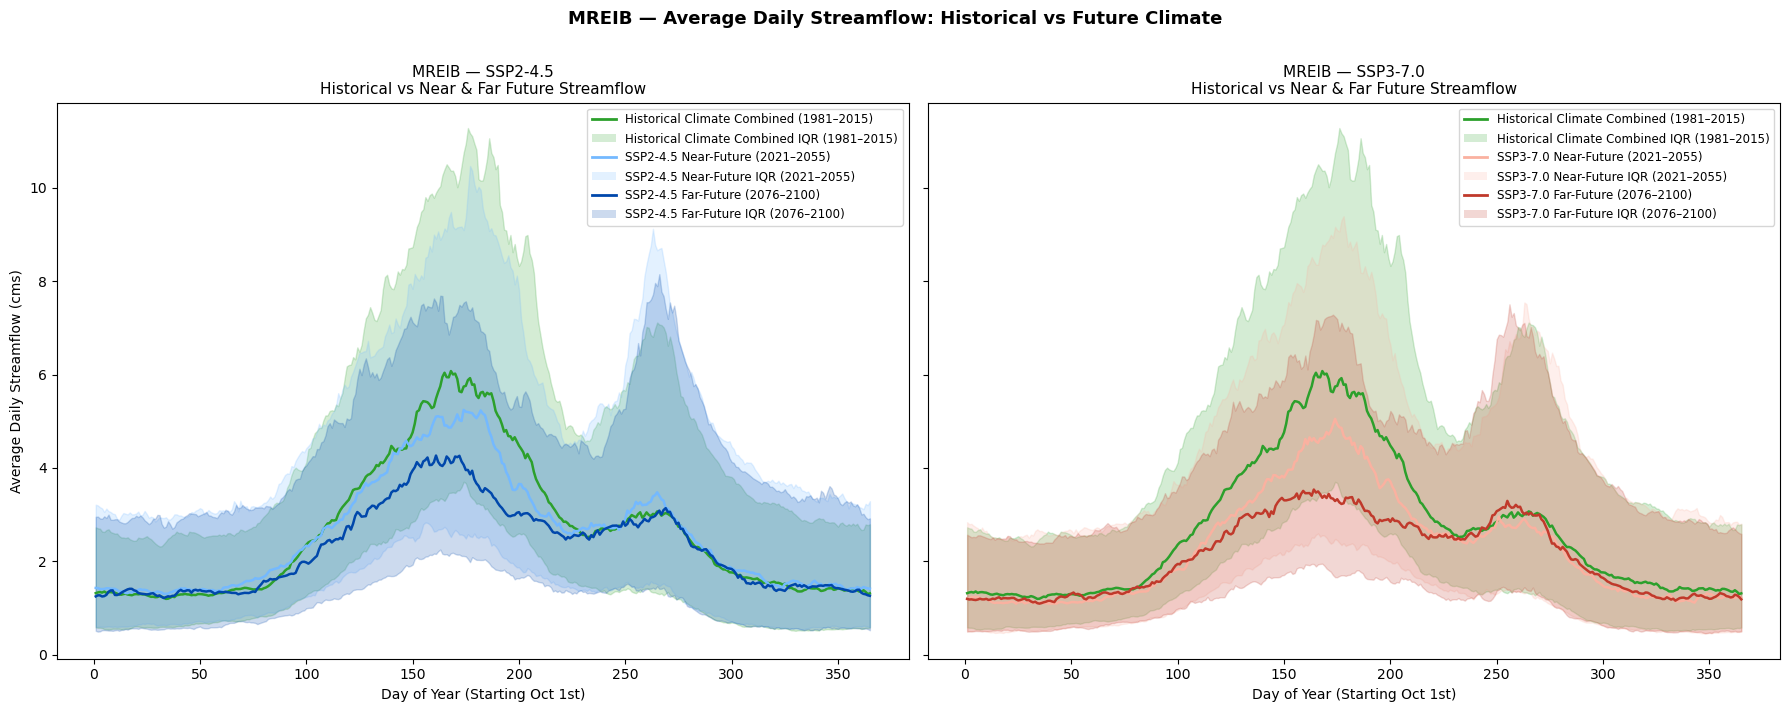

In [35]:
plot_pseudohistorical_vs_future_splitssp(
    hist_ssp245=mreib_hist_ssp245,
    hist_ssp370=mreib_hist_ssp370,
    ssp245_near=mreib_ssp245_near,
    ssp370_near=mreib_ssp370_near,
    ssp245_far=mreib_ssp245_far,
    ssp370_far=mreib_ssp370_far,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='MREIB'
)

In [38]:
def plot_pseudohistorical_vs_future_splitperiod(
    hist_ssp245: xr.DataArray,
    hist_ssp370: xr.DataArray,
    ssp245_near: xr.DataArray,
    ssp370_near: xr.DataArray,
    ssp245_far: xr.DataArray,
    ssp370_far: xr.DataArray,
    variable_name: str,
    variable_unit: str,
    variable: str,
    output_directory: str,
    basin_name: str
):
    historical_color = '#2ca02c'
    near_color1      = '#74b9ff'
    far_color1       = '#0047AB'
    near_color2      = '#fab1a0'
    far_color2       = '#c0392b'

    def get_stats(data):
        stacked = data.stack(sample=('member', 'year'))
        return (
            stacked.median(dim='sample'),
            stacked.quantile(0.25, dim='sample'),
            stacked.quantile(0.75, dim='sample'),
        )

    hist_combined = xr.concat([hist_ssp245, hist_ssp370], dim='member')
    doy = hist_combined['dayofyear'].values

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    panel_configs = [
        {
            'ax':    axes[0],
            'title': 'Near-Future (2021–2055)',
            'traces': [
                (hist_combined, historical_color, 'Historical Climate Combined (1981–2015)'),
                (ssp245_near,   near_color1,      'SSP2-4.5 Near-Future (2021–2055)'),
                (ssp370_near,   near_color2,      'SSP3-7.0 Near-Future (2021–2055)'),
            ],
        },
        {
            'ax':    axes[1],
            'title': 'Far-Future (2076–2100)',
            'traces': [
                (hist_combined, historical_color, 'Historical Climate Combined (1981–2015)'),
                (ssp245_far,    far_color1,       'SSP2-4.5 Far-Future (2076–2100)'),
                (ssp370_far,    far_color2,       'SSP3-7.0 Far-Future (2076–2100)'),
            ],
        },
    ]

    for cfg in panel_configs:
        ax = cfg['ax']
        legend_handles = []

        for data, color, label in cfg['traces']:
            median, q25, q75 = get_stats(data)
            ax.plot(doy, median, color=color, linestyle='-', lw=1.8)
            ax.fill_between(doy, q25, q75, color=color, alpha=0.2)
            legend_handles += [
                Line2D([0], [0], color=color, lw=2, label=label),
                Patch(facecolor=color, alpha=0.2,
                      label=label.replace('(', 'IQR (')),
            ]

        ax.set_title(f'{basin_name} — {cfg["title"]}\n'
                     f'Historical vs Both SSPs — {variable_name}',
                     fontsize=11)
        ax.set_xlabel('Day of Year (Starting Oct 1st)')
        ax.legend(handles=legend_handles, fontsize=8.5, loc='best')

    axes[0].set_ylabel(f'Average Daily {variable_name} ({variable_unit})')
    axes[1].set_ylabel('')

    fig.suptitle(
        f'{basin_name} — Average Daily {variable_name}: Historical vs Future Climate',
        fontsize=13, fontweight='bold', y=1.01
    )

    plt.tight_layout()
    file_path = os.path.join(
        output_directory,
        f'{basin_name}_historical_climate_vs_future_{variable}_split_period.png'
    )
    plt.savefig(file_path, bbox_inches='tight', dpi=300)
    plt.show()

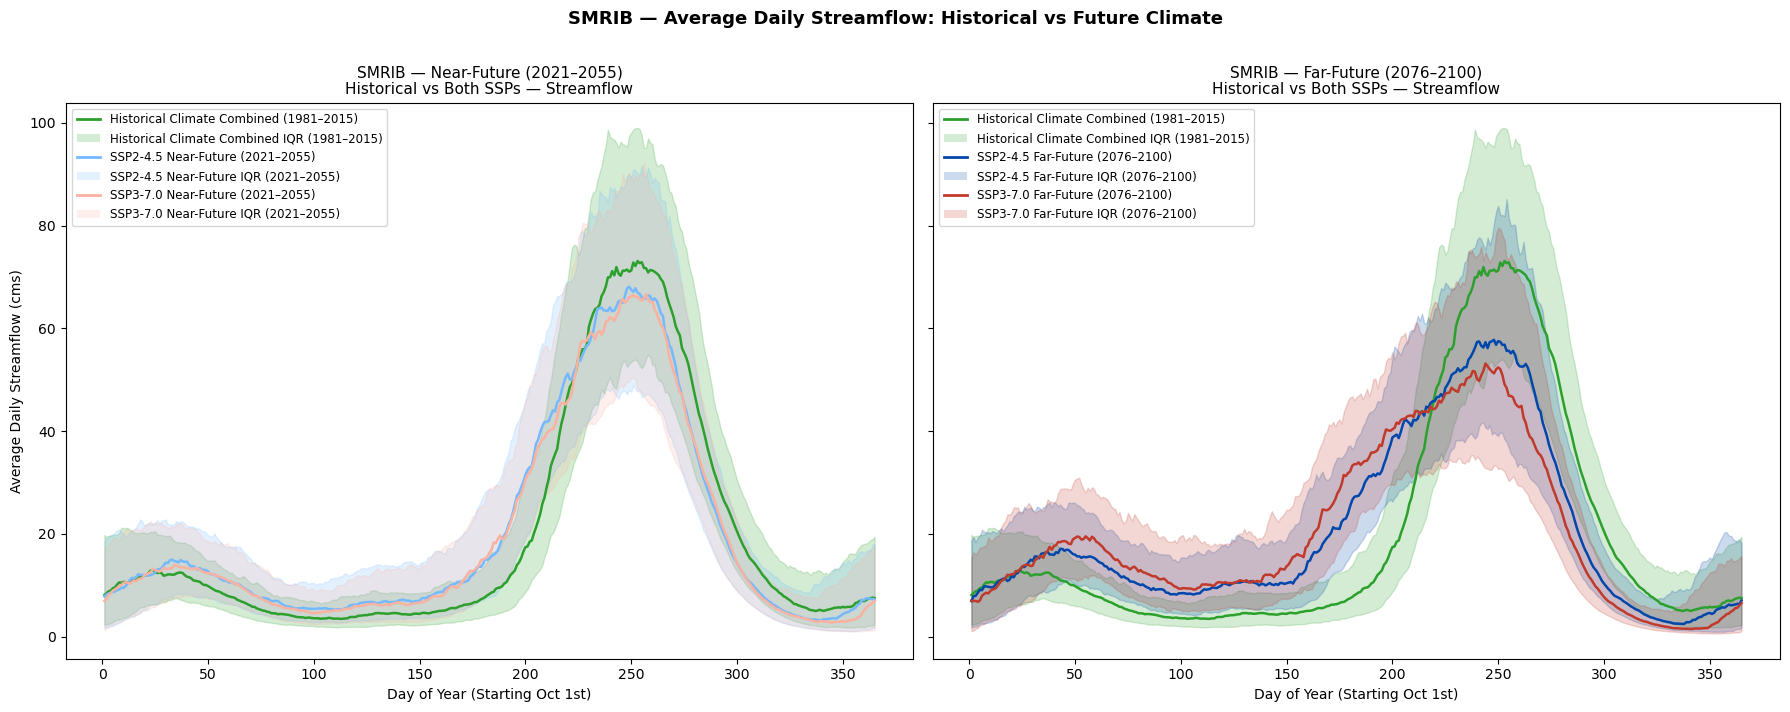

In [39]:
plot_pseudohistorical_vs_future_splitperiod(
    hist_ssp245=smrib_hist_ssp245,
    hist_ssp370=smrib_hist_ssp370,
    ssp245_near=smrib_ssp245_near,
    ssp370_near=smrib_ssp370_near,
    ssp245_far=smrib_ssp245_far,
    ssp370_far=smrib_ssp370_far,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='SMRIB'
)

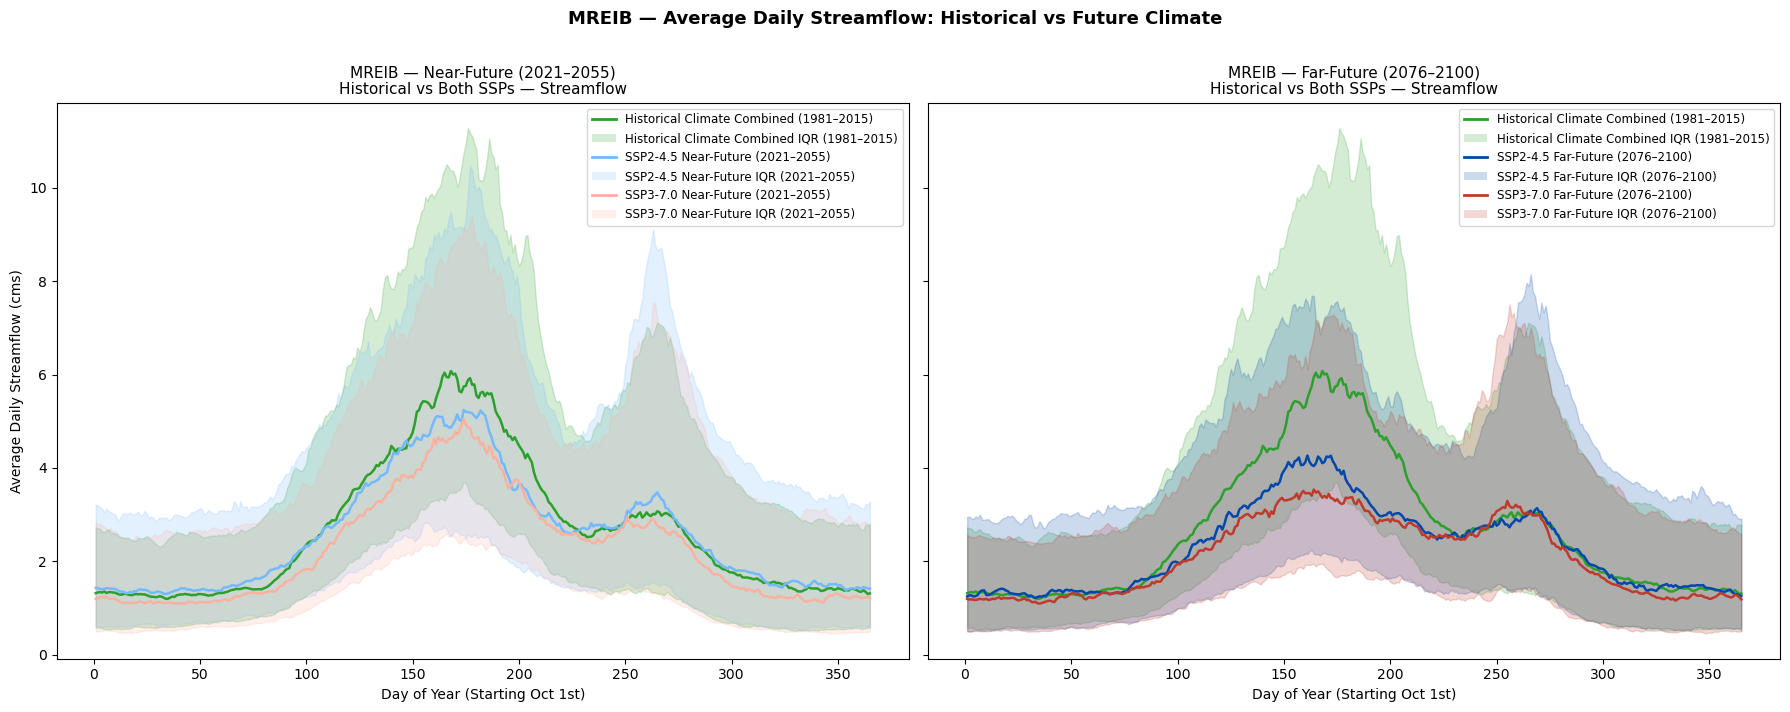

In [40]:
plot_pseudohistorical_vs_future_splitperiod(
    hist_ssp245=mreib_hist_ssp245,
    hist_ssp370=mreib_hist_ssp370,
    ssp245_near=mreib_ssp245_near,
    ssp370_near=mreib_ssp370_near,
    ssp245_far=mreib_ssp245_far,
    ssp370_far=mreib_ssp370_far,
    variable_name=variable_name,
    variable_unit=variable_unit,
    variable=variable,
    output_directory=output_directory,
    basin_name='MREIB'
)